# 🌿 PlantPulse AI — Exploratory Data Analysis
## Dataset: AI4I 2020 Predictive Maintenance Dataset

---

This notebook performs a structured exploratory data analysis (EDA) on the **AI4I 2020 Predictive Maintenance** dataset.
The goal is to understand the data's shape, quality, class distribution, feature distributions, and correlations
before building any machine-learning model.

**Why EDA matters:**  
Rushing straight to modelling without understanding your data is one of the most common mistakes in ML projects.
EDA reveals hidden problems (missing values, severe class imbalance, feature skew) that directly affect model
performance and determine which algorithms and resampling strategies are appropriate.


In [1]:
# ── Core imports ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Notebook display settings ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': '#0f0f0f',
                     'axes.facecolor': '#1a1a2e', 'axes.labelcolor': '#e0e0e0',
                     'xtick.color': '#c0c0c0', 'ytick.color': '#c0c0c0',
                     'text.color': '#e0e0e0', 'grid.color': '#2a2a4a',
                     'axes.titlecolor': '#ffffff', 'axes.edgecolor': '#3a3a5c'})

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


---
## 1 · Load the Dataset

We begin by loading the raw CSV file into a pandas `DataFrame`.  
The first thing to verify is the dataset's **shape** (rows × columns), the **column names**,
and the **data types** of each column — this tells us immediately whether pandas has inferred
numeric vs. categorical columns correctly and whether any manual type-casting will be needed.


In [2]:
# ── Resolve the path to the CSV relative to this notebook ─────────────────────
NOTEBOOK_DIR = Path().resolve()          # ml-service/notebooks/
DATA_PATH    = NOTEBOOK_DIR / '../../data/ai4i2020.csv'

assert DATA_PATH.exists(), f'Dataset not found at: {DATA_PATH.resolve()}'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded from : {DATA_PATH.resolve()}')
print(f'Shape               : {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('── Column names ──────────────────────────────')
print(df.columns.tolist())
print()
print('── Data types ────────────────────────────────')
print(df.dtypes)
print()
print('── First 5 rows ──────────────────────────────')
df.head()

Dataset loaded from : C:\projects\plantpulse-ai\data\ai4i2020.csv
Shape               : 10,000 rows × 14 columns

── Column names ──────────────────────────────
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

── Data types ────────────────────────────────
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

── First 5 rows ──────────────────────────────


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


---
## 2 · Data Quality Check — Missing Values & Duplicates

Before any analysis, we must confirm the dataset is **complete and unique**.  

- **Missing values** can silently corrupt statistics and model training if not handled.  
- **Duplicate rows** inflate counts and skew distributions, leading to misleading insights
  and overly optimistic evaluation metrics (data leakage between train/test splits).

A clean dataset here means we can proceed without imputation or de-duplication.


In [3]:
# ── Missing values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

quality_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
}).sort_values('Missing Count', ascending=False)

print('── Missing Values per Column ──────────────────────────────────────')
print(quality_df[quality_df['Missing Count'] > 0] if missing.sum() > 0
      else '✓  No missing values found.')

# ── Duplicate rows ─────────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'\n── Duplicate Rows ─────────────────────────────────────────────────')
print(f'✓  {n_dupes} duplicate rows found.' if n_dupes == 0
      else f'⚠  {n_dupes} duplicate rows found — consider dropping them.')

# ── Quick statistical summary ──────────────────────────────────────────────────
print('\n── Descriptive Statistics ─────────────────────────────────────────')
df.describe()

── Missing Values per Column ──────────────────────────────────────
✓  No missing values found.

── Duplicate Rows ─────────────────────────────────────────────────
✓  0 duplicate rows found.

── Descriptive Statistics ─────────────────────────────────────────


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,300.0049,310.0056,1538.7761,39.9869,107.9510,0.0339,0.0046,0.0115,0.0095,0.0098,0.0019
std,2886.8957,2.0003,1.4837,179.2841,9.9689,63.6541,0.1810,0.0677,0.1066,0.0970,0.0985,0.0435
min,1.0000,295.3000,305.7000,1168.0000,3.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2500.7500,298.3000,308.8000,1423.0000,33.2000,53.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,5000.5000,300.1000,310.1000,1503.0000,40.1000,108.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,7500.2500,301.5000,311.1000,1612.0000,46.8000,162.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,10000.0000,304.5000,313.8000,2886.0000,76.6000,253.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## 3 · Target Variable Analysis — Machine Failure & Failure Types

This is a **multi-label binary classification** problem. The dataset contains:

| Column | Meaning |
|---|---|
| `Machine failure` | **Primary target** — 1 if any failure occurred, 0 otherwise |
| `TWF` | Tool Wear Failure |
| `HDF` | Heat Dissipation Failure |
| `PWF` | Power Failure |
| `OSF` | Overstrain Failure |
| `RNF` | Random Failure |

Understanding the **absolute count** and **relative frequency** of each failure type is critical:
- Some failure types may be extremely rare, making them harder to model individually.
- Class imbalance (many more 0s than 1s) is the defining challenge in predictive maintenance.


── Target Column Value Counts ─────────────────────────────────────

  Machine failure:
    0 (No Failure) : 9,661  (96.61%)
    1 (Failure)    :   339  (3.39%)

  TWF:
    0 (No Failure) : 9,954  (99.54%)
    1 (Failure)    :    46  (0.46%)

  HDF:
    0 (No Failure) : 9,885  (98.85%)
    1 (Failure)    :   115  (1.15%)

  PWF:
    0 (No Failure) : 9,905  (99.05%)
    1 (Failure)    :    95  (0.95%)

  OSF:
    0 (No Failure) : 9,902  (99.02%)
    1 (Failure)    :    98  (0.98%)

  RNF:
    0 (No Failure) : 9,981  (99.81%)
    1 (Failure)    :    19  (0.19%)




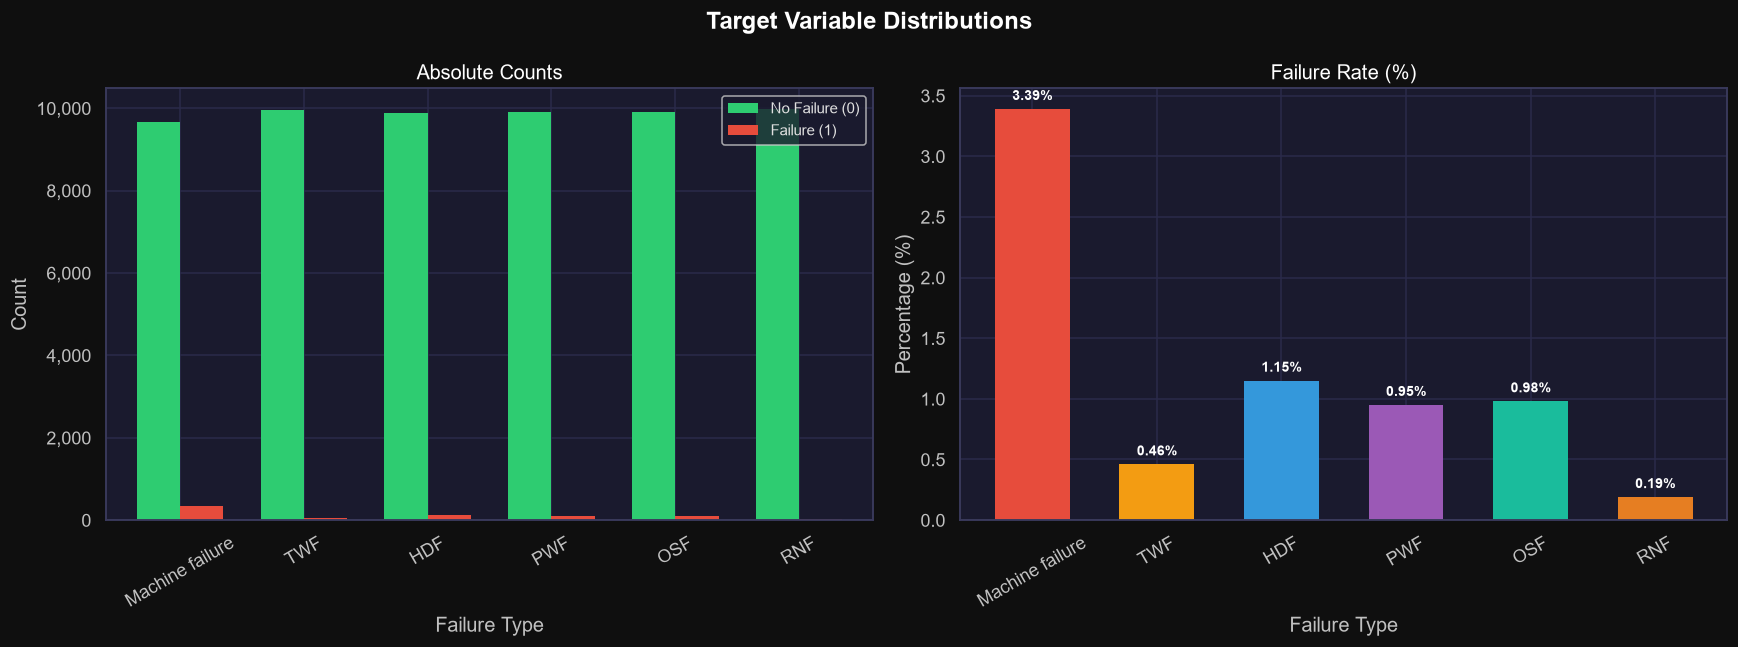

✓ Plot saved to ml-service/outputs/target_distributions.png


In [4]:
TARGET_COLS = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print('── Target Column Value Counts ─────────────────────────────────────')
for col in TARGET_COLS:
    vc = df[col].value_counts().sort_index()
    pct_pos = df[col].mean() * 100
    print(f'\n  {col}:')
    print(f'    0 (No Failure) : {vc.get(0, 0):>5,}  ({100-pct_pos:.2f}%)')
    print(f'    1 (Failure)    : {vc.get(1, 0):>5,}  ({pct_pos:.2f}%)')

print('\n')

# ── Stacked bar chart of all target columns ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Target Variable Distributions', fontsize=16, fontweight='bold', color='#ffffff')

# Left: absolute counts
counts_df = pd.DataFrame(
    {col: df[col].value_counts().reindex([0, 1]).values for col in TARGET_COLS},
    index=['No Failure (0)', 'Failure (1)']
).T

counts_df.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
               edgecolor='none', width=0.7)
axes[0].set_title('Absolute Counts', color='white')
axes[0].set_xlabel('Failure Type', color='#c0c0c0')
axes[0].set_ylabel('Count', color='#c0c0c0')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: failure % only
failure_pct = {col: df[col].mean() * 100 for col in TARGET_COLS}
colors_bar  = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c', '#e67e22']
axes[1].bar(TARGET_COLS, failure_pct.values(), color=colors_bar, edgecolor='none', width=0.6)
axes[1].set_title('Failure Rate (%)', color='white')
axes[1].set_xlabel('Failure Type', color='#c0c0c0')
axes[1].set_ylabel('Percentage (%)', color='#c0c0c0')
axes[1].tick_params(axis='x', rotation=30)
for i, (col, pct) in enumerate(failure_pct.items()):
    axes[1].text(i, pct + 0.05, f'{pct:.2f}%', ha='center', va='bottom',
                 fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/target_distributions.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Plot saved to ml-service/outputs/target_distributions.png')

---
## 4 · Class Imbalance Analysis

**Class imbalance** is the central challenge in predictive maintenance datasets.  
In real industrial settings, machines fail rarely — so failure events are a tiny fraction of total observations.

A naïve classifier that always predicts "no failure" would achieve very high accuracy simply
because failures are so infrequent. This is why **accuracy alone is a misleading metric** here;
we need **Precision, Recall, F1-score**, and **AUC-ROC** instead.

This section quantifies the imbalance ratio and visualises it with a pie chart and a summary table.
This analysis will directly inform our choice of resampling strategies (e.g., SMOTE from `imbalanced-learn`)
or class-weight adjustments during model training.


── Primary Target: Machine failure ────────────────────────────────
  Total samples      : 10,000
  No Failure (0)     : 9,661  (96.61%)
  Failure    (1)     : 339    (3.39%)
  Imbalance ratio    : 28.5:1  (non-failure : failure)

  ⚠  This level of imbalance requires specialised handling:
     → Use SMOTE / class-weight parameters during training
     → Evaluate with F1-score, Precision-Recall AUC, not just accuracy


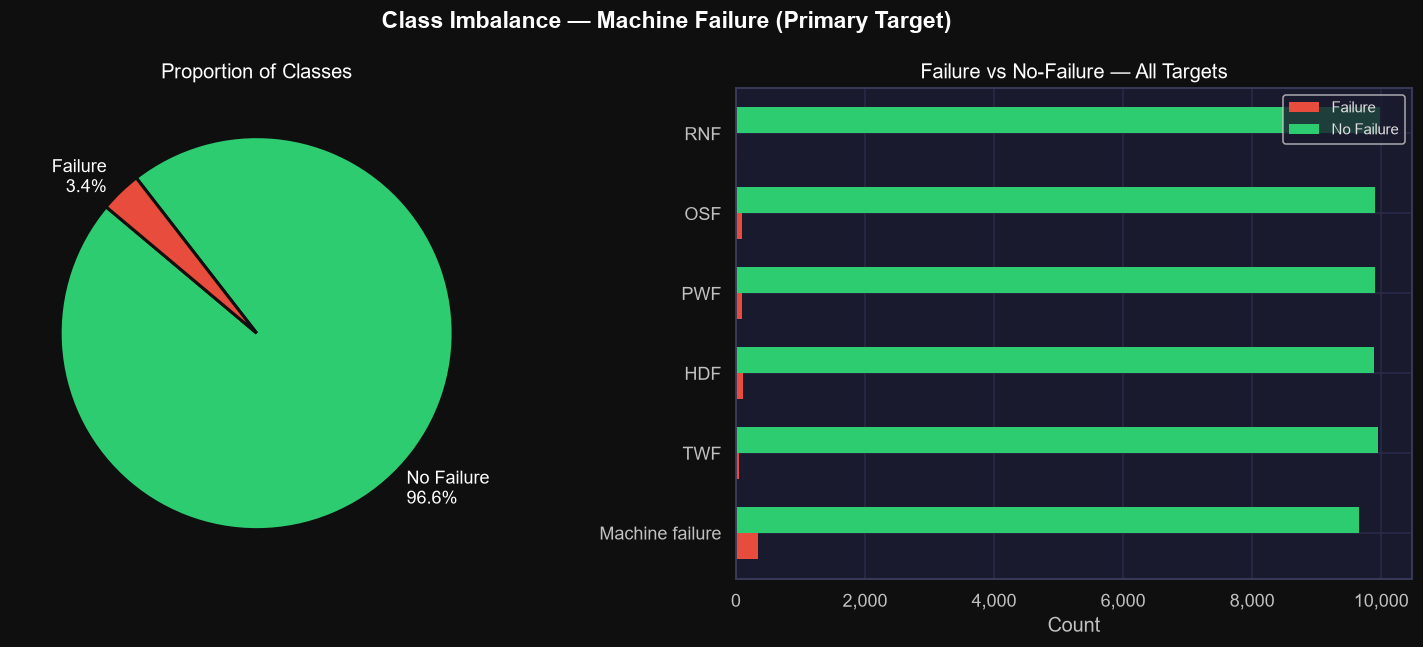

✓ Plot saved to ml-service/outputs/class_imbalance.png


In [5]:
total        = len(df)
n_failure    = df['Machine failure'].sum()
n_no_failure = total - n_failure
imbalance_ratio = n_no_failure / n_failure

print('── Primary Target: Machine failure ────────────────────────────────')
print(f'  Total samples      : {total:,}')
print(f'  No Failure (0)     : {n_no_failure:,}  ({n_no_failure/total*100:.2f}%)')
print(f'  Failure    (1)     : {n_failure:,}    ({n_failure/total*100:.2f}%)')
print(f'  Imbalance ratio    : {imbalance_ratio:.1f}:1  (non-failure : failure)')
print()
print('  ⚠  This level of imbalance requires specialised handling:')
print('     → Use SMOTE / class-weight parameters during training')
print('     → Evaluate with F1-score, Precision-Recall AUC, not just accuracy')

# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Class Imbalance — Machine Failure (Primary Target)',
             fontsize=15, fontweight='bold', color='white')

# Pie chart
sizes  = [n_no_failure, n_failure]
labels = [f'No Failure\n{n_no_failure/total*100:.1f}%',
          f'Failure\n{n_failure/total*100:.1f}%']
axes[0].pie(sizes, labels=labels, colors=['#2ecc71', '#e74c3c'],
            startangle=140, wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2},
            textprops={'color': 'white', 'fontsize': 12})
axes[0].set_title('Proportion of Classes', color='white')

# Summary bar for all failure types
imb_data = {col: (df[col].sum(), total - df[col].sum()) for col in TARGET_COLS}
imb_df   = pd.DataFrame(imb_data, index=['Failure', 'No Failure']).T
imb_df.plot(kind='barh', ax=axes[1], color=['#e74c3c', '#2ecc71'],
            edgecolor='none', width=0.65)
axes[1].set_title('Failure vs No-Failure — All Targets', color='white')
axes[1].set_xlabel('Count', color='#c0c0c0')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/class_imbalance.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Plot saved to ml-service/outputs/class_imbalance.png')

---
## 5 · Sensor Feature Distributions

The five sensor readings are the core input features for our predictive model:

| Feature | Unit | Physical Meaning |
|---|---|---|
| `Air temperature [K]` | Kelvin | Ambient temperature around the machine |
| `Process temperature [K]` | Kelvin | Temperature of the manufacturing process |
| `Rotational speed [rpm]` | RPM | Speed of the rotating component |
| `Torque [Nm]` | Newton-metres | Torque applied by the motor |
| `Tool wear [min]` | Minutes | Cumulative tool wear time |

Plotting histograms for each feature helps us identify:
- **Skewness** — which may require log-transformation before training certain models
- **Outliers** — extreme sensor readings that could indicate sensor faults or genuine anomalies
- **Bimodal / multimodal patterns** — suggesting different operating regimes or machine types

We overlay the distribution separately for **failure** and **non-failure** samples
to see whether sensor readings differ between the two classes.


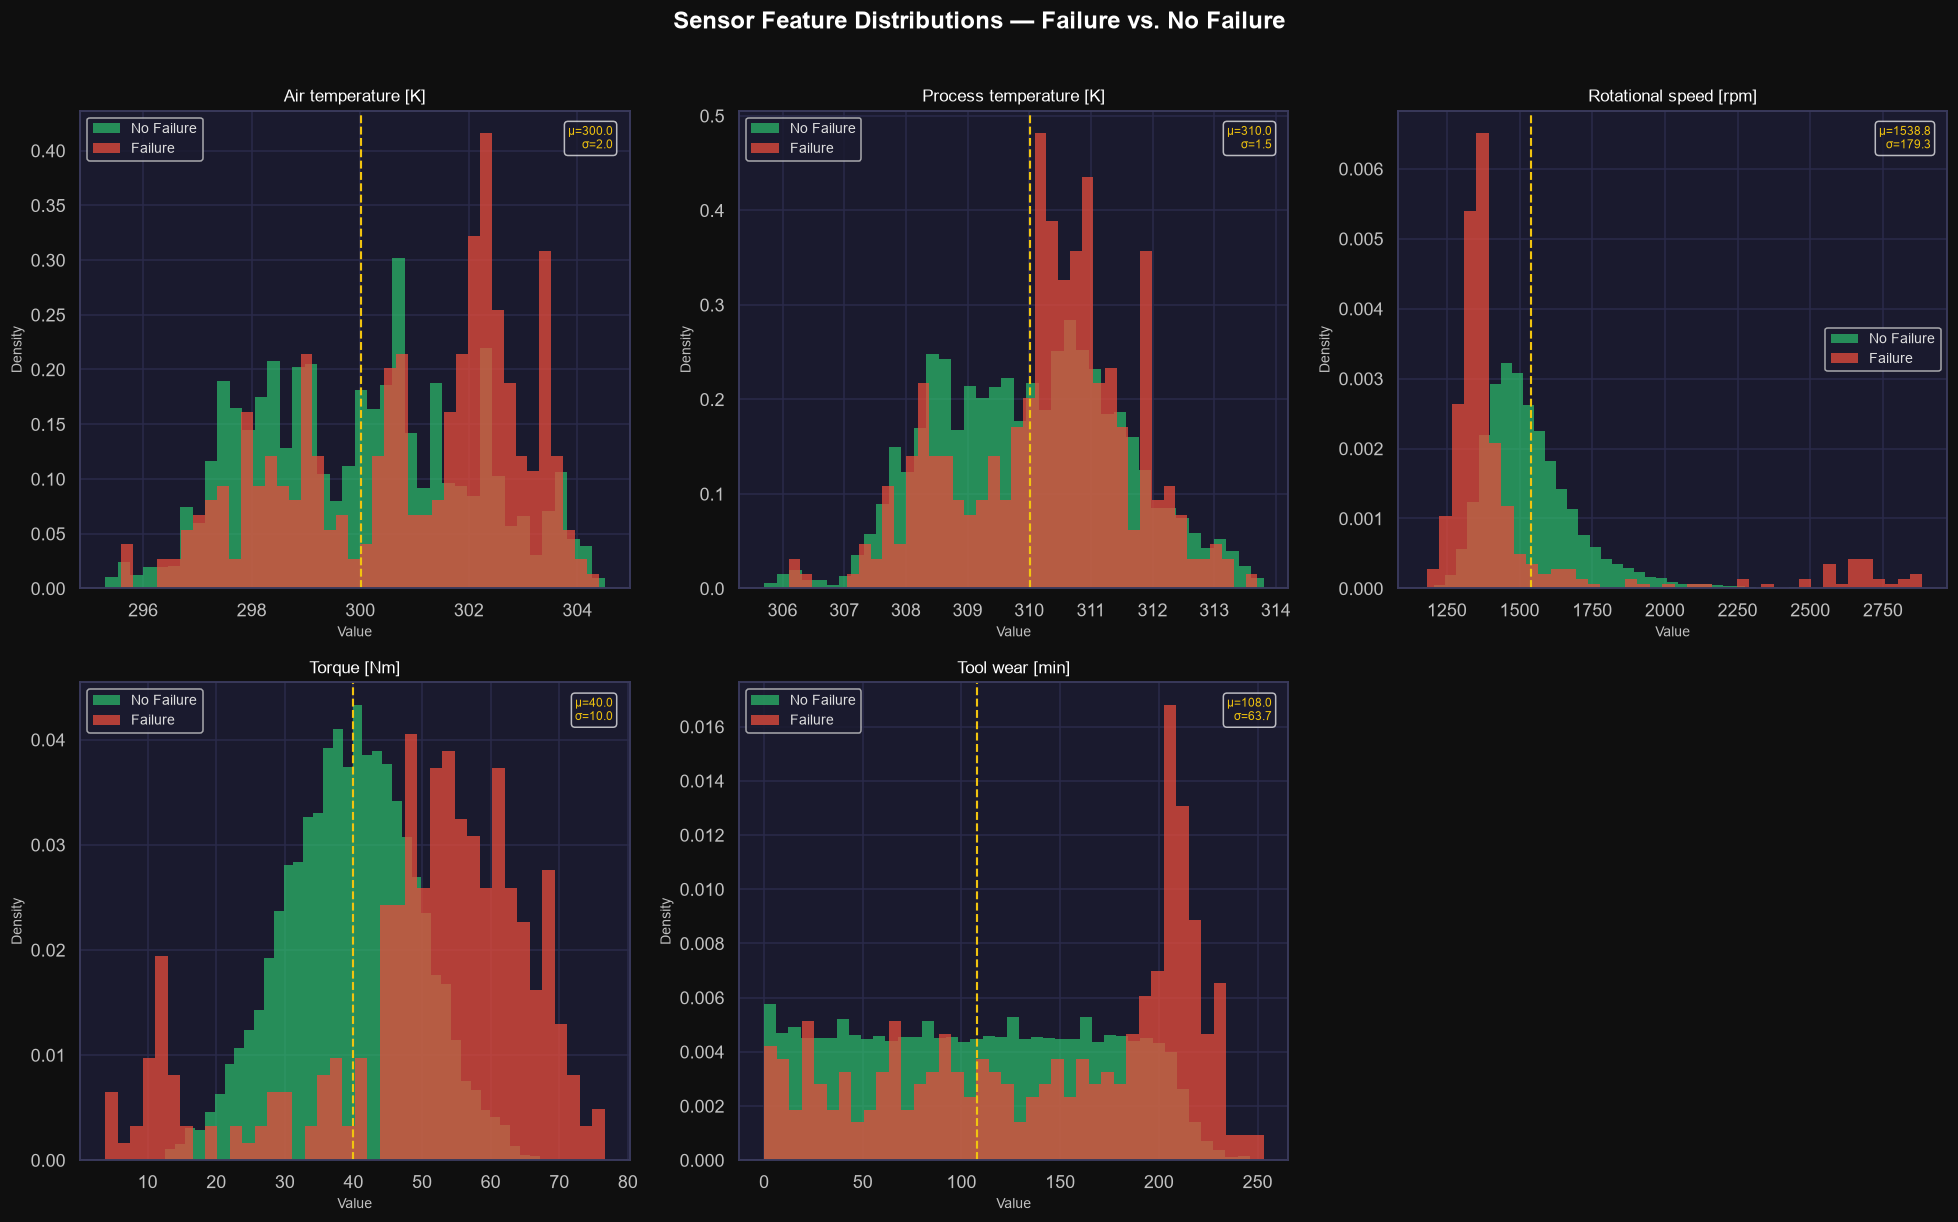

✓ Plot saved to ml-service/outputs/sensor_distributions.png


In [6]:
SENSOR_FEATURES = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df_fail   = df[df['Machine failure'] == 1]
df_nofail = df[df['Machine failure'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Sensor Feature Distributions — Failure vs. No Failure',
             fontsize=16, fontweight='bold', color='white', y=1.01)
axes_flat = axes.flatten()

PALETTE = {'No Failure': '#2ecc71', 'Failure': '#e74c3c'}

for idx, feat in enumerate(SENSOR_FEATURES):
    ax = axes_flat[idx]
    ax.hist(df_nofail[feat], bins=40, color=PALETTE['No Failure'],
            alpha=0.65, label='No Failure', edgecolor='none', density=True)
    ax.hist(df_fail[feat],   bins=40, color=PALETTE['Failure'],
            alpha=0.75, label='Failure',    edgecolor='none', density=True)
    ax.set_title(feat, fontsize=11, color='white')
    ax.set_xlabel('Value', fontsize=9, color='#c0c0c0')
    ax.set_ylabel('Density', fontsize=9, color='#c0c0c0')
    ax.legend(fontsize=9)

    # ── Overlay descriptive stats as text ──────────────────────────────────────
    mean_all = df[feat].mean()
    std_all  = df[feat].std()
    ax.axvline(mean_all, color='#f1c40f', linewidth=1.4, linestyle='--', label='Mean')
    ax.text(0.97, 0.97, f'μ={mean_all:.1f}\nσ={std_all:.1f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#f1c40f',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', alpha=0.7))

# Hide the empty 6th subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/sensor_distributions.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Plot saved to ml-service/outputs/sensor_distributions.png')

---
## 6 · Correlation Heatmap — Numeric Features vs. Machine Failure

A **correlation heatmap** shows the pairwise linear relationship between all numeric features.
Key things we are looking for:

1. **Which features correlate most strongly with `Machine failure`?**  
   High correlation (positive or negative) suggests the feature will be informative for the model.

2. **Are any input features highly correlated with each other (multicollinearity)?**  
   High inter-feature correlation can cause instability in linear models (e.g., logistic regression).
   Tree-based models (XGBoost, Random Forest) are generally robust to multicollinearity.

3. **Unexpected near-zero correlations** with the target may suggest we need feature engineering
   or non-linear transformations.

> Note: Pearson correlation captures **linear** relationships only.
> Non-linear relationships (important for tree models) will not show up here.


── Top correlations with  "Machine failure" ─────────────────────────
                         Pearson r
HDF                         0.5758
OSF                         0.5311
PWF                         0.5228
TWF                         0.3629
Torque [Nm]                 0.1913
Tool wear [min]             0.1054
Air temperature [K]         0.0826
Rotational speed [rpm]     -0.0442
Process temperature [K]     0.0359
RNF                         0.0045


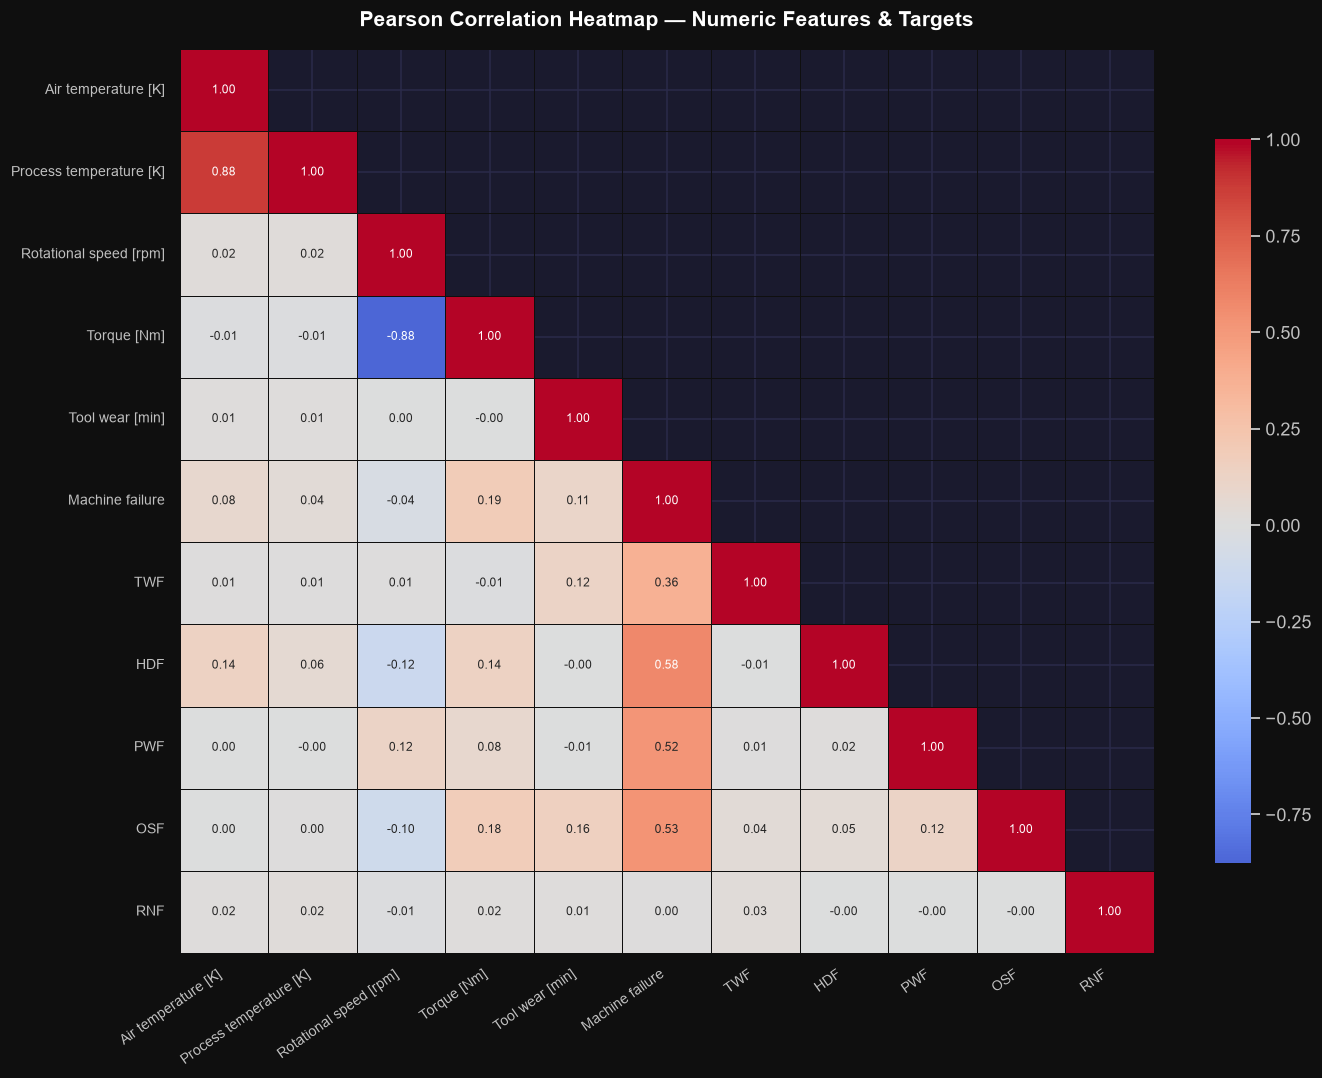

✓ Plot saved to ml-service/outputs/correlation_heatmap.png


In [7]:
NUMERIC_COLS = SENSOR_FEATURES + TARGET_COLS

corr_matrix = df[NUMERIC_COLS].corr()

# ── Print top correlates with Machine failure ──────────────────────────────────
print('── Top correlations with  "Machine failure" ─────────────────────────')
corr_with_target = (corr_matrix['Machine failure']
                    .drop('Machine failure')
                    .sort_values(key=abs, ascending=False))
print(corr_with_target.to_frame().rename(columns={'Machine failure': 'Pearson r'}))

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    linecolor='#0f0f0f',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Heatmap — Numeric Features & Targets',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(axis='both', labelsize=9)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Plot saved to ml-service/outputs/correlation_heatmap.png')

---
## 7 · EDA Summary & Key Takeaways

This section consolidates our findings into actionable conclusions for the next phase of development.


In [8]:
print('=' * 65)
print('  PLANTPULSE AI — EDA SUMMARY')
print('=' * 65)

print(f"""
📊 Dataset
  • {df.shape[0]:,} rows  ×  {df.shape[1]} columns
  • Zero missing values  |  Zero duplicate rows

🎯 Class Imbalance  (Machine failure)
  • Failure rate : {df['Machine failure'].mean()*100:.2f}%
  • Imbalance ratio : {(df['Machine failure']==0).sum()}/{(df['Machine failure']==1).sum()} = {imbalance_ratio:.1f}:1
  ➜  Strategy : SMOTE oversampling + class_weight='balanced' in models

📡 Sensor Features
  • Air temp & Process temp are tightly correlated (expected — process heat ↑ air heat)
  • Torque and Rotational speed show moderate negative correlation
  • Tool wear distribution is roughly uniform — machines replaced at varying intervals

🔗 Top Correlates with Machine failure
""")
for feat, corr_val in corr_with_target.head(5).items():
    bar = '█' * int(abs(corr_val) * 30)
    print(f"  {feat:<40} r = {corr_val:+.4f}  {bar}")

print("""
📌 Next Steps
  1. Feature engineering  →  power = torque × speed; temp_diff = process_temp − air_temp
  2. Encode 'Type' (machine variant) as a categorical feature
  3. Train baseline models: Logistic Regression, Random Forest, XGBoost
  4. Apply SMOTE and evaluate with F1-macro, Precision-Recall AUC
  5. SHAP analysis for feature importance and explainability
""")
print('=' * 65)

  PLANTPULSE AI — EDA SUMMARY

📊 Dataset
  • 10,000 rows  ×  14 columns
  • Zero missing values  |  Zero duplicate rows

🎯 Class Imbalance  (Machine failure)
  • Failure rate : 3.39%
  • Imbalance ratio : 9661/339 = 28.5:1
  ➜  Strategy : SMOTE oversampling + class_weight='balanced' in models

📡 Sensor Features
  • Air temp & Process temp are tightly correlated (expected — process heat ↑ air heat)
  • Torque and Rotational speed show moderate negative correlation
  • Tool wear distribution is roughly uniform — machines replaced at varying intervals

🔗 Top Correlates with Machine failure

  HDF                                      r = +0.5758  █████████████████
  OSF                                      r = +0.5311  ███████████████
  PWF                                      r = +0.5228  ███████████████
  TWF                                      r = +0.3629  ██████████
  Torque [Nm]                              r = +0.1913  █████

📌 Next Steps
  1. Feature engineering  →  power = torque 